✅ Added /home/amoleri/PycharmProjects/FederatedFactory/src to path
✅ Models imported successfully
📂 Scanning directory: /home/amoleri/PycharmProjects/FederatedFactory/commands/checkpoints
🔎 Found 19 checkpoints.

🚀 Using Device: cpu

[1/19] Processing: medmnist_bloodmnist/dirichlet_0.1/client0/class_0/checkpoint-client-client0_c0-epoch-0500.pt
   🎨 Generating 5 samples (28px, 3ch)...


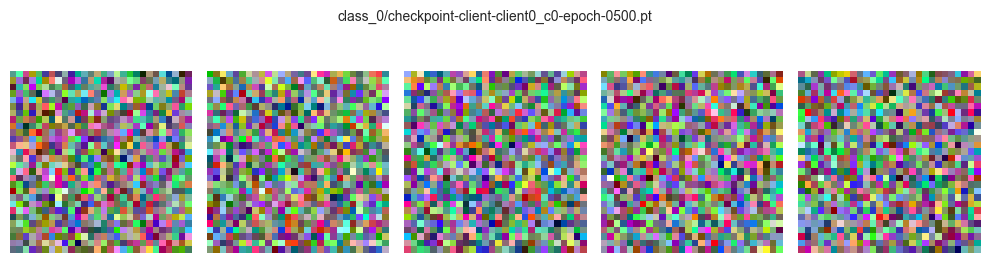


[2/19] Processing: medmnist_bloodmnist/dirichlet_0.1/client0/class_0/checkpoint-client-client0_c0-epoch-1000.pt
   🎨 Generating 5 samples (28px, 3ch)...


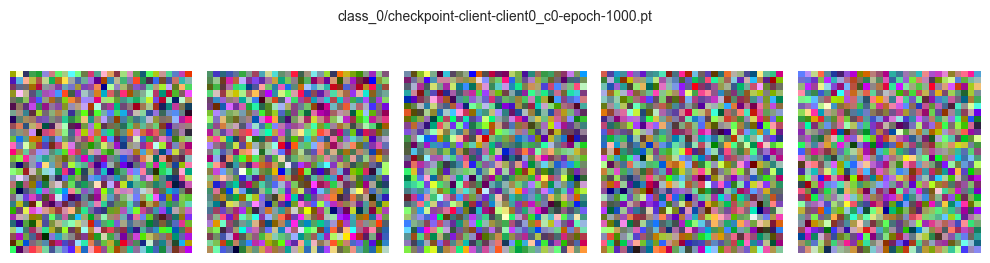


[3/19] Processing: medmnist_bloodmnist/dirichlet_0.1/client0/class_0/checkpoint-client-client0_c0-epoch-1500.pt
   🎨 Generating 5 samples (28px, 3ch)...


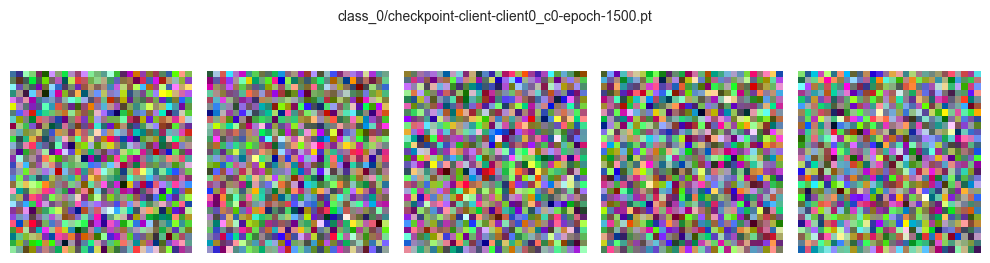


[4/19] Processing: medmnist_bloodmnist/dirichlet_0.1/client0/class_0/checkpoint-client-client0_c0-epoch-2000.pt
   🎨 Generating 5 samples (28px, 3ch)...


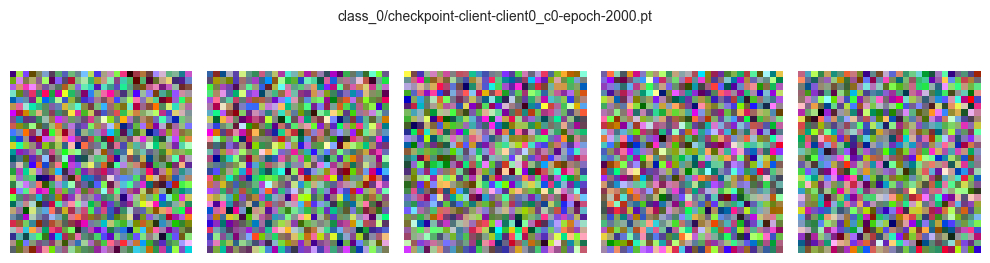


[5/19] Processing: medmnist_bloodmnist/dirichlet_0.1/client0/class_0/checkpoint-client-client0_c0-epoch-2500.pt
   🎨 Generating 5 samples (28px, 3ch)...


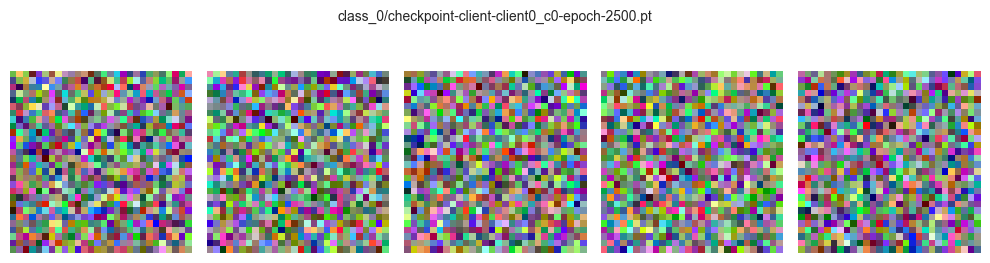


[6/19] Processing: medmnist_bloodmnist/dirichlet_0.1/client0/class_0/checkpoint-client-client0_c0-epoch-3000.pt
   🎨 Generating 5 samples (28px, 3ch)...


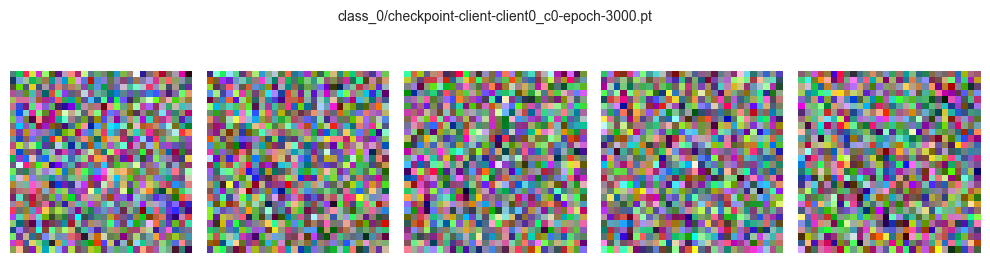


[7/19] Processing: medmnist_bloodmnist/dirichlet_0.1/client0/class_0/checkpoint-client-client0_c0-epoch-3500.pt
   🎨 Generating 5 samples (28px, 3ch)...


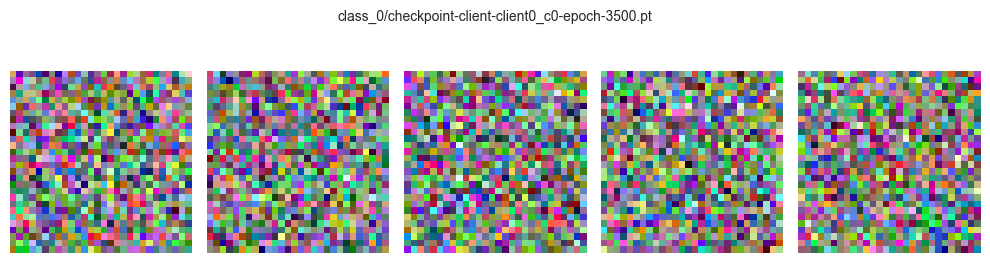


[8/19] Processing: medmnist_bloodmnist/dirichlet_0.1/client0/class_0/checkpoint-client-client0_c0-epoch-4000.pt
   🎨 Generating 5 samples (28px, 3ch)...


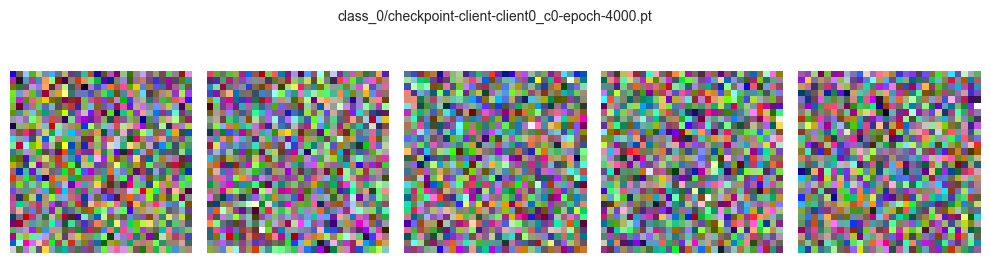


[9/19] Processing: medmnist_bloodmnist/dirichlet_0.1/client0/class_0/checkpoint-client-client0_c0-epoch-4500.pt
   🎨 Generating 5 samples (28px, 3ch)...


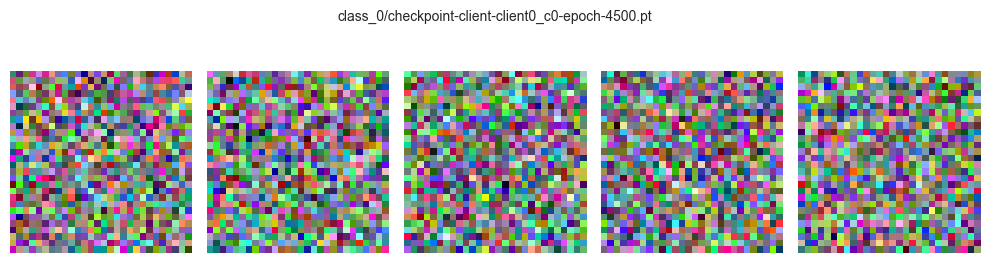


[10/19] Processing: medmnist_retinamnist/dirichlet_0.1/client0/class_0/checkpoint-client-client0_c0-epoch-0500.pt
   🎨 Generating 5 samples (28px, 3ch)...


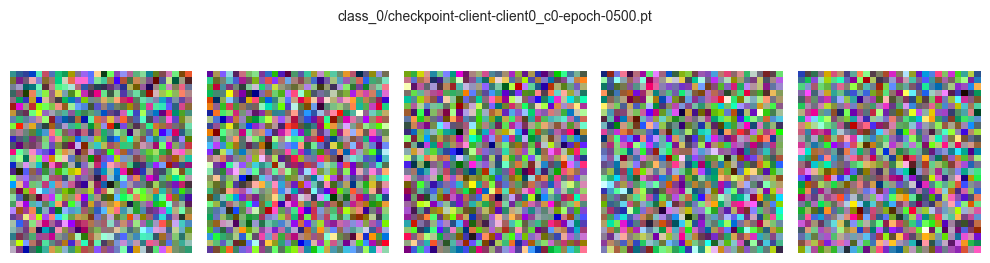


[11/19] Processing: medmnist_retinamnist/dirichlet_0.1/client0/class_0/checkpoint-client-client0_c0-epoch-1000.pt
   🎨 Generating 5 samples (28px, 3ch)...


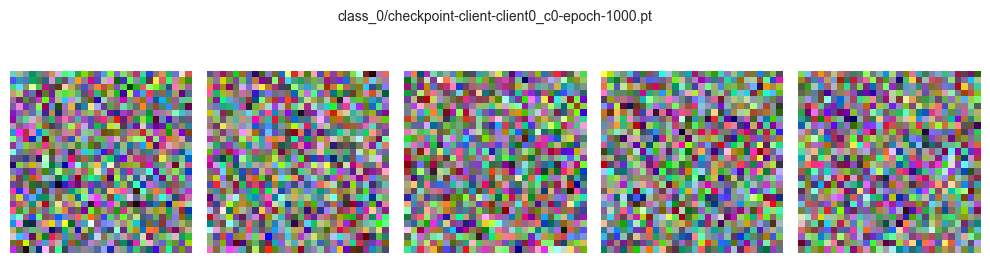


[12/19] Processing: medmnist_retinamnist/dirichlet_0.1/client0/class_0/checkpoint-client-client0_c0-epoch-1500.pt
   🎨 Generating 5 samples (28px, 3ch)...


In [ ]:
# %% [markdown]
# # Checkpoint Validation & Generation Scanner
#
# This notebook scans the `commands/checkpoints/` directory.
# For every checkpoint found, it:
# 1. Infers the model configuration (Channels/Resolution) from the folder path.
# 2. Loads the DiT model.
# 3. Generates 5 synthetic images to verify the frozen core is working.

# %%
import sys
import os
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. SETUP PATHS
# ==========================================
# Ensure 'src' is in the python path
PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / "src").exists():
    sys.path.append(str(PROJECT_ROOT / "src"))
    print(f"✅ Added {PROJECT_ROOT}/src to path")
else:
    raise FileNotFoundError("Could not find 'src' directory. Run this notebook from the project root (andreamoleri-federatedfactory).")

# Import internal modules
try:
    from models.diffusion import DiT, DiffusionConfig, rectified_flow_sampler
    print("✅ Models imported successfully")
except ImportError as e:
    print(f"❌ Failed to import models: {e}")
    print("Ensure you have installed the requirements (EDM2 submodule dependencies).")

# %%
# ==========================================
# 2. CONFIGURATION & INFERENCE UTILITIES
# ==========================================

def infer_config_from_path(ckpt_path: Path):
    """
    Infers the DiT configuration based on the dataset name found in the file path.
    Matches logic from src/checkpoint_trainer.py and src/imports/data_management.py
    """
    path_str = str(ckpt_path).lower()

    # --- DEFAULTS ---
    embed_dim = 128
    dropout = 0.30
    num_classes = 0 # Checkpoints are usually class-specific (unconditional models)

    # --- 1. RESOLUTION & CHANNELS HEURISTICS ---

    # A. MedMNIST Logic (Usually 28x28)
    if "medmnist" in path_str:
        res = 28
        channel_mult = [1, 2, 2] # Specific to 28x28 in trainer script

        # Channel inference based on MedMNIST subsets
        # GrayScale: Organ, OCT, Pneumonia, Tissue, Breast
        if any(x in path_str for x in ["organ", "oct", "pneumonia", "tissue", "breast"]):
            in_ch = 1
        # RGB: Path, Blood, Retina, Derma
        else:
            in_ch = 3

    # B. CIFAR Logic (32x32)
    elif "cifar" in path_str:
        res = 32
        channel_mult = [1, 2, 2, 2]
        in_ch = 3

    # C. ISIC / Medical High Res (Assume 32 or 64 for testing baselines unless specified)
    elif "isic" in path_str:
        # Based on typical settings in this repo for lower compute
        res = 32
        channel_mult = [1, 2, 2, 2]
        in_ch = 3

    # D. Default Fallback
    else:
        print(f"⚠️ Warning: Could not infer config for {ckpt_path.parent.name}, assuming 32x32 RGB")
        res = 32
        in_ch = 3
        channel_mult = [1, 2, 2, 2]

    # Create Config Object
    cfg = DiffusionConfig(
        in_ch=in_ch,
        embed_dim=embed_dim,
        channel_mult=channel_mult,
        dropout=dropout,
        img_resolution=res,
        num_classes=num_classes
    )

    return cfg

def show_images(tensors, title="Generated"):
    """
    Displays a row of tensors.
    Expects tensors in range [-1, 1] (DiT output)
    """
    # Denormalize [-1, 1] -> [0, 1]
    tensors = (tensors.detach().cpu() + 1) / 2.0
    tensors = tensors.clamp(0, 1)

    n = len(tensors)
    fig, axes = plt.subplots(1, n, figsize=(n * 2, 2.5))
    if n == 1: axes = [axes]

    for i, ax in enumerate(axes):
        img = tensors[i].permute(1, 2, 0).numpy()
        # Handle Grayscale
        if img.shape[2] == 1:
            img = img.squeeze(2)
            ax.imshow(img, cmap="gray")
        else:
            ax.imshow(img)
        ax.axis("off")

    fig.suptitle(title, fontsize=10, y=1.05)
    plt.tight_layout()
    plt.show()

# %%
# ==========================================
# 3. SCANNER & GENERATOR
# ==========================================

def scan_and_generate():
    # 1. Locate Checkpoints Directory
    # We check both 'commands/checkpoints' (where script output goes) and root 'checkpoints'
    possible_paths = [
        PROJECT_ROOT / "commands" / "checkpoints",
        PROJECT_ROOT / "checkpoints"
    ]

    ckpt_root = None
    for p in possible_paths:
        if p.exists():
            ckpt_root = p
            break

    if ckpt_root is None:
        print(f"❌ Could not find checkpoints directory in:")
        for p in possible_paths: print(f"   - {p}")
        print("Run 'commands/run_checkpoints.sh' first.")
        return

    print(f"📂 Scanning directory: {ckpt_root}")

    # 2. Find all .pt files (recursively)
    checkpoints = sorted(list(ckpt_root.rglob("*.pt")))

    if not checkpoints:
        print("⚠️ No .pt files found in checkpoints directory.")
        return

    print(f"🔎 Found {len(checkpoints)} checkpoints.\n")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 Using Device: {device}")

    # 3. Loop and Generate
    for i, ckpt in enumerate(checkpoints):
        # Pretty print path (e.g., medmnist_bloodmnist/silos/client_0/class_0/...)
        rel_path = ckpt.relative_to(ckpt_root)
        print(f"\n[{i+1}/{len(checkpoints)}] Processing: {rel_path}")

        try:
            # A. Config
            cfg = infer_config_from_path(ckpt)

            # B. Initialize
            model = DiT(cfg).to(device)

            # C. Load Weights
            # Map location ensures we don't OOM if saving on multi-gpu
            chkpt_data = torch.load(ckpt, map_location=device)

            # Extract state_dict if wrapped (e.g. 'model', 'state_dict', 'ema')
            if isinstance(chkpt_data, dict):
                if "state_dict" in chkpt_data:
                    state_dict = chkpt_data["state_dict"]
                elif "model" in chkpt_data:
                    state_dict = chkpt_data["model"]
                elif "ema" in chkpt_data:
                    state_dict = chkpt_data["ema"]
                else:
                    # Assume it is the state dict itself
                    state_dict = chkpt_data
            else:
                state_dict = chkpt_data

            # Remove DDP prefixes if present ('module.')
            clean_state_dict = {}
            for k, v in state_dict.items():
                if k.startswith("module."):
                    clean_state_dict[k[7:]] = v
                else:
                    clean_state_dict[k] = v

            # Load (strict=True to ensure architecture matches exact expectations)
            model.load_state_dict(clean_state_dict, strict=True)
            model.eval()

            # D. Generate
            print(f"   🎨 Generating 5 samples ({cfg.img_resolution}px, {cfg.in_ch}ch)...")
            with torch.no_grad():
                # Steps=20 is sufficient for a quick visual check (Rectified Flow)
                samples = rectified_flow_sampler(
                    model,
                    n=5,
                    shape=(cfg.in_ch, cfg.img_resolution, cfg.img_resolution),
                    steps=20,
                    device=device
                )

            # E. Display
            show_images(samples, title=f"{rel_path.parent.name}/{ckpt.name}")

            # Cleanup
            del model
            del samples
            torch.cuda.empty_cache()

        except RuntimeError as e:
            if "size mismatch" in str(e):
                print(f"❌ Size Mismatch: The logic inferred config {cfg}, but weights didn't match.")
                print("   Likely the 'channel_mult' or 'resolution' inference logic needs adjustment.")
            else:
                print(f"❌ Runtime Error: {e}")
        except Exception as e:
            print(f"❌ Error processing {ckpt.name}: {e}")

# %%
# ==========================================
# 4. EXECUTE
# ==========================================
if __name__ == "__main__":
    scan_and_generate()